In [1]:
import pickle as pk
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)

import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)

from jax import config
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import colossus 
import configobj

from base_class import base_class
from get_radial_profiles import Profiles
from get_Pkzs import get_Pkz
from get_Cls import get_Cl
from get_Xis import get_xi
from get_covs import get_cov

%load_ext autoreload
%autoreload 2

    


/tmp/ipykernel_3326540/4069794190.py:10: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1


In [2]:
def get_samps(fname, acorr_max = 0.075, acorr_min = 0.0075):
    df = pk.load(open(fname,'rb'))
    sig8 = df['sigma8']
    nchains = 64
    sig8_rs = sig8.reshape(nchains,-1)
    # print(sig8_rs.shape)
    from numpyro.diagnostics import autocorrelation, autocovariance
    
    acorr = autocorrelation(sig8_rs, axis=1)
    ind_del = []
    for ji in range(acorr.shape[0]):
        if (np.std(acorr[ji,100:]) > acorr_max) or (np.std(acorr[ji,100:]) < acorr_min):
            ind_del.append(ji)    
    print(len(ind_del))
    samps = []
    keys = []
    for key in df:
        if ('base' not in key) and ('decentered' not in key):
            if key not in ['RUN_SETTINGS', 'diverging', 'potential_energy']:
            # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging', 'potential_energy']:
                if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                    for jb in range(4):
                        samps.append(df[key][:, jb])
                        keys.append(key + '_' + str(jb))
                        # print(df[key][:, jb].shape)
                # print(samps[0].shape)
                # print(df[key].shape)
                else:
                    samps.append(df[key])
                    keys.append(key)
    
    samps = np.array(samps).T
    ind_sigma8 = keys.index('sigma8')
    # ind_thetaejM = keys.index('nu_theta_ej_M')
    ind_Om = keys.index('Om0')
    samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5
    
    samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
    keys.append('S8')
    
    import getdist
    from getdist import plots, MCSamples
    
    names = keys    
    ind_frac_rm = 0.5
    # nchains = 80
    samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
    nsamp_per_chain = samps_sel.shape[1]
    nrm = int(ind_frac_rm * nsamp_per_chain)
    samps_sel = samps_sel[:, nrm:, :]
    
    if len(ind_del) > 0:
        samps_sel = np.delete(samps_sel, ind_del, axis=0)
    else:
        samps_sel = samps_sel
    
    samps = samps_sel.reshape(-1, samps_sel.shape[-1])
    print(samps.shape, samps_sel.shape)
    return samps, keys





In [3]:
ldir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/'
# samps_all = get_MCsamps(ldir + 'mcmc_v9_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_4500_warmup_3500_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
# samps_gty = get_MCsamps(ldir + 'mcmc_v9_probe_gty_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_4000_warmup_3000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
# samps_xipm = get_MCsamps(ldir + 'mcmc_v9_probe_xip_xim_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_4500_warmup_3500_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')

samps, keys = get_samps(ldir + 'mcmc_v10_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_7000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')





8
(224000, 22) (56, 4000, 22)


In [4]:
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_v9_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_4000_warmup_3000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))
# # df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_probe_all_deproj_cib_1p7_dBeta_2000_4000_num_chains_32.pkl','rb'))
# # df.keys()
# sig8 = df['sigma8']
# # nchains = 80
# nchains = 64
# sig8_rs = sig8.reshape(nchains,-1)
# # print(sig8_rs.shape)
# from numpyro.diagnostics import autocorrelation, autocovariance

# acorr = autocorrelation(sig8_rs, axis=1)
# ind_del = []
# for ji in range(acorr.shape[0]):
#     if np.std(acorr[ji,100:]) > 0.075:
#         ind_del.append(ji)

# print(len(ind_del), ind_del)



In [5]:
# samps = []
# keys = []
# for key in df:
#     # if ('base' not in key) and ('decentered' not in key):
#         # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging']:
#         if key not in ['RUN_SETTINGS', 'diverging']:
#             if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
#                 for jb in range(4):
#                     samps.append(df[key][:, jb])
#                     keys.append(key + '_' + str(jb))
#                     print(df[key][:, jb].shape)
#             else:
#                 samps.append(df[key])
#                 keys.append(key)            

# samps = np.array(samps).T
# ind_sigma8 = keys.index('sigma8')
# ind_Om = keys.index('Om0')
# samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5

# samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
# keys.append('S8')



# samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
# nsamp_per_chain = samps_sel.shape[1]
# if len(ind_del) > 0:
#     samps_sel = np.delete(samps_sel, ind_del, axis=0)
# else:
#     samps_sel = samps_sel

# samps = samps_sel.reshape(-1, samps_sel.shape[-1])
# print(samps.shape, samps_sel.shape)


In [9]:
# samps.shape
nsamp_tot = samps.shape[0]
# indsel = np.sort(np.random.randint(0, nsamp_tot, 128))
# indsel = np.sort(np.random.randint(0, nsamp_tot, 64))
indsel = np.sort(np.random.randint(0, nsamp_tot, 8))
indsel



array([ 19431,  26179,  39244,  49612,  63791, 123866, 124900, 171475])

In [10]:
import warnings
warnings.filterwarnings("ignore")


In [11]:
from tqdm import tqdm

# ind_post = keys.index('potential_energy')
# post = -1.* samps[:,ind_post]

# map_ind = np.where(post == post.max())[0][0]

Y_model_all_samp = []

for map_ind in tqdm(indsel):
# for map_ind in tqdm(indsel[:2]):    
    saved_bestfit = {}
    for jk, key in enumerate(keys):
        # print(key, samps[map_ind, jk])
        saved_bestfit[key] = samps[map_ind, jk]
    
    # potential_energy -4916.635080802822
    import yaml
    import pathlib
    curr_path = pathlib.Path().absolute()
    abs_path_data = os.path.abspath(curr_path / "../../data/") 
    abs_path_src = os.path.abspath(curr_path / "../../src/") 
    abs_path_results = os.path.abspath(curr_path / "../../results/") 
    abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
    
    from deepmerge import always_merger
    def read_yaml(file_path):
        with open(file_path, 'r') as file:
            data = yaml.safe_load(file)
        return data
    
    def generate_dicts(data):
        sim_params_dict = data.get('sim_params', {})
        halo_params_dict = data.get('halo_params', {})
        analysis_dict = data.get('analysis', {})
        other_params_dict = data.get('other_params', {})
        return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict
    
    default_data = read_yaml(abs_path_params + '/params_default.yaml')
    new_data = read_yaml(abs_path_params + '/DESxACT/params_v2.yaml')
    # new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
    merged_data = always_merger.merge(default_data, new_data)
    
    sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)
    
    
    # saved_bestift
    from astropy.io import fits
    df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
    z_array = df['nz_source'].data['Z_MID']
    nz_info_dict = {}
    nz_info_dict['z_array_source'] = z_array
    nz_info_dict['nbins'] = 4
    for ji in range(nz_info_dict['nbins']):
        nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
    analysis_dict['nz_source_info_dict'] = nz_info_dict
    other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
    other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
    
    
    analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]
    
    lmin, lmax, dl_log_array = 10.0, 61000.0, 0.23025851
    l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
    dl_array = l_array_all[1:] - l_array_all[:-1]
    l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
    halo_params_dict['ell_array'] = jnp.array(l_array_survey)
    analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
    analysis_dict['dl_array_survey'] = jnp.array(dl_array)
    
    
    for key in saved_bestfit.keys():
        if key in list(sim_params_dict.keys()):
            sim_params_dict[key] = float(saved_bestfit[key])
        if key in list(sim_params_dict['cosmo'].keys()):
            sim_params_dict['cosmo'][key] = float(saved_bestfit[key])
            if key == 'h':
                sim_params_dict['cosmo']['H0'] = 100*saved_bestfit[key]
        if key in list(other_params_dict.keys()):
            other_params_dict[key] = float(saved_bestfit[key])
    for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
        other_params_dict['Delta_z_bias_array'][jb] = saved_bestfit[f'Delta_z_bias_array_{jb}']
    for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
        other_params_dict['mult_shear_bias_array'][jb] = saved_bestfit[f'mult_shear_bias_array_{jb}']
    
    base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
    profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
    
    
    h = sim_params_dict['cosmo']['H0'] / 100.0
    Ob = sim_params_dict['cosmo']['Ob0']
    Om = sim_params_dict['cosmo']['Om0']
    import astropy.units as u
    from astropy import constants as const
    import jax_cosmo.background as bkgrd
    sigmat = const.sigma_T
    m_e = const.m_e
    c = const.c
    coeff = sigmat / (m_e * (c ** 2))
    oneMpc_h_to_cm = (((10 ** 6)/h) * (u.pc).to(u.cm))
    const_coeff = ((coeff).to(((u.kpc ** 2) / u.keV))).value
    
    from scipy.interpolate import interp1d
    import jax_cosmo.background as bkgrd
    z_array = profiles_test.z_array
    scale_fac_a_array = 1.0 / (1.0 + z_array)
    indz = 0
    # indz = 8    
    Ez = np.sqrt(bkgrd.growth_factor(profiles_test.cosmo_jax, scale_fac_a_array))[indz]
    # M200_noh = M_array[indM]/h
    h70 = h/0.7
    M_array = profiles_test.M_array
    Y_model_all = np.zeros(len(M_array))
    Y_ss_all = np.zeros(len(M_array))
    for jM in range(len(M_array)):
        Mj = M_array[jM]
        M200_noh = Mj/h
        # Y_ss = 97.6 * (1/h70) * (Ez**(2/3.)) * (M200_noh/(1e15/h70))**(5/3.) * (Ob/0.043) * (0.25/Om)
    
        # r200_jM = BCMP_test.r200c_mat[jM, indz]
        r200_jM = profiles_test.r200c_mat[indz, jM]    
        r_array_jM = np.logspace(-3, np.log10(r200_jM), 100)
        Pe_jz_jM = profiles_test.Pe_mat_physical[:, indz, jM]
        interpPe = interp1d(np.log(profiles_test.r_array), np.log(Pe_jz_jM), fill_value='extrapolate')
        Pe_jM = np.exp(interpPe(np.log(r_array_jM)))
        Y_jM = np.trapz(4 * np.pi * r_array_jM**3 * Pe_jM, np.log(r_array_jM))
    
        Y_model_all[jM] = const_coeff * Y_jM * (oneMpc_h_to_cm**3)
        # Y_ss_all[jM] = Y_ss
        
    Y_model_all_samp.append(Y_model_all)



  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:47<00:00,  5.99s/it]


In [12]:
# np.save('Y_model_all.npz',Y_model_all_samp)
Y_model_all_samp = np.array(Y_model_all_samp)



In [13]:
# Y_model_all_samp.shape
Ymin = np.percentile(Y_model_all_samp, 16, axis=0)
Ymax = np.percentile(Y_model_all_samp, 84, axis=0)


In [14]:
# Ymin
import matplotlib
%matplotlib inline


In [15]:
import sys, os
import yaml
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 

from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

# yaml_file_path = '/mnt/home/spandey/ceph/GODMAX/param_files/params_default.yaml'
default_data = read_yaml(abs_path_params + '/params_default.yaml')
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(default_data)

from get_B12_profile import Battaglia_12_16
import helpers.constants as constants
# cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 69.0, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8':0.81 ,'ns': 0.965}
cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 69.0, 'Om0': 0.25, 'Ob0': 0.043, 'sigma8':0.81 ,'ns': 0.965}
B12_test = Battaglia_12_16({'cosmo':cosmo_params_dict, 'init_power':False}, halo_params_dict)
h = sim_params_dict['cosmo']['H0'] / 100.0
Ob = sim_params_dict['cosmo']['Ob0']
Om = sim_params_dict['cosmo']['Om0']
import astropy.units as u
from astropy import constants as const
import jax_cosmo.background as bkgrd
sigmat = const.sigma_T
m_e = const.m_e
c = const.c
coeff = sigmat / (m_e * (c ** 2))
oneMpc_h_to_cm = (((10 ** 6)/h) * (u.pc).to(u.cm))
const_coeff = ((coeff).to(((u.kpc ** 2) / u.keV))).value

from scipy.interpolate import interp1d
import jax_cosmo.background as bkgrd
z_array = B12_test.z_array
scale_fac_a_array = 1.0 / (1.0 + z_array)
# indz = 0
indz = 0
# Ez = np.sqrt(bkgrd.growth_factor(profiles_test.cosmo_jax, scale_fac_a_array))[indz]
# M200_noh = M_array[indM]/h
h70 = h/0.7
M_array = B12_test.M_array
Y_B12_all = np.zeros(len(M_array))
# Y_ss_all = np.zeros(len(M_array))
for jM in range(len(M_array)):
    Mj = M_array[jM]
    M200_noh = Mj/h
    # Y_ss = 97.6 * (1/h70) * (Ez**(2/3.)) * (M200_noh/(1e15/h70))**(5/3.) * (Ob/0.043) * (0.25/Om)

    # r200_jM = BCMP_test.r200c_mat[jM, indz]
    r200_jM = B12_test.r200c_mat[jM, indz]    
    r_array_jM = np.logspace(-3, np.log10(r200_jM), 100)
    Pe_jz_jM = B12_test.Pe_mat_physical[:, indz, jM]
    interpPe = interp1d(np.log(B12_test.r_array), np.log(Pe_jz_jM), fill_value='extrapolate')
    Pe_jM = np.exp(interpPe(np.log(r_array_jM)))
    Y_jM = np.trapz(4 * np.pi * r_array_jM**3 * Pe_jM, np.log(r_array_jM))

    Y_B12_all[jM] = const_coeff * Y_jM * (oneMpc_h_to_cm**3)
    # Y_ss_all[jM] = Y_ss





In [16]:
import sys, os
import yaml
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
from get_OWLS_profile import LeBrun15
import helpers.constants as constants
import astropy.units as u
from astropy import constants as const
import jax_cosmo.background as bkgrd
from scipy.interpolate import interp1d
import jax_cosmo.background as bkgrd

from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

# yaml_file_path = '/mnt/home/spandey/ceph/GODMAX/param_files/params_default.yaml'
default_data = read_yaml(abs_path_params + '/params_default.yaml')
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(default_data)
halo_params_dict['nr'] = 64
# halo_params_dict['nM'] = 64


# cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 69.0, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8':0.81 ,'ns': 0.965}
cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 67.1, 'Om0': 0.27, 'Ob0': 0.0455, 'sigma8':0.81 ,'ns': 0.965}
owls_test = LeBrun15({'cosmo':cosmo_params_dict, 'init_power':False, 'owls_type':'ref'}, halo_params_dict)
h = sim_params_dict['cosmo']['H0'] / 100.0
Ob = sim_params_dict['cosmo']['Ob0']
Om = sim_params_dict['cosmo']['Om0']
sigmat = const.sigma_T
m_e = const.m_e
c = const.c
coeff = sigmat / (m_e * (c ** 2))
oneMpc_h_to_cm = (((10 ** 6)/h) * (u.pc).to(u.cm))
const_coeff = ((coeff).to(((u.kpc ** 2) / u.keV))).value

z_array = owls_test.z_array
scale_fac_a_array = 1.0 / (1.0 + z_array)
indz = 0
h70 = h/0.7
M_array = owls_test.M_array
Y_owls_all_ref = np.zeros(len(M_array))
for jM in range(len(M_array)):
    r200_jM = owls_test.r200c_mat[jM, indz]    
    r_array_jM = np.logspace(-2, np.log10(r200_jM), 100)
    Pe_jz_jM = owls_test.Pe_mat_physical[:, indz, jM]
    interpPe = interp1d(np.log(owls_test.r_array), np.log(Pe_jz_jM), fill_value='extrapolate')
    Pe_jM = np.exp(interpPe(np.log(r_array_jM)))
    Y_jM = np.trapz(4 * np.pi * r_array_jM**3 * Pe_jM, np.log(r_array_jM))

    Y_owls_all_ref[jM] = const_coeff * Y_jM * (oneMpc_h_to_cm**3)
    # Y_ss_all[jM] = Y_ss

cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 67.1, 'Om0': 0.27, 'Ob0': 0.0455, 'sigma8':0.81 ,'ns': 0.965}
owls_test = LeBrun15({'cosmo':cosmo_params_dict, 'init_power':False, 'owls_type':'agn_8p5'}, halo_params_dict)
h = sim_params_dict['cosmo']['H0'] / 100.0
Ob = sim_params_dict['cosmo']['Ob0']
Om = sim_params_dict['cosmo']['Om0']
sigmat = const.sigma_T
m_e = const.m_e
c = const.c
coeff = sigmat / (m_e * (c ** 2))
oneMpc_h_to_cm = (((10 ** 6)/h) * (u.pc).to(u.cm))
const_coeff = ((coeff).to(((u.kpc ** 2) / u.keV))).value

z_array = owls_test.z_array
scale_fac_a_array = 1.0 / (1.0 + z_array)
indz = 0
h70 = h/0.7
M_array = owls_test.M_array
Y_owls_all_agn = np.zeros(len(M_array))
for jM in range(len(M_array)):
    r200_jM = owls_test.r200c_mat[jM, indz]    
    r_array_jM = np.logspace(-2, np.log10(r200_jM), 100)
    Pe_jz_jM = owls_test.Pe_mat_physical[:, indz, jM]
    interpPe = interp1d(np.log(owls_test.r_array), np.log(Pe_jz_jM), fill_value='extrapolate')
    Pe_jM = np.exp(interpPe(np.log(r_array_jM)))
    Y_jM = np.trapz(4 * np.pi * r_array_jM**3 * Pe_jM, np.log(r_array_jM))

    Y_owls_all_agn[jM] = const_coeff * Y_jM * (oneMpc_h_to_cm**3)




In [13]:
# halo_params_dict
# r_array_jM
# owls_test.r500c_mat[20,0]
# owls_test.fb


In [60]:
# len(M_array)
# owls_test.get_params_pressure('P0', 20, 0)
# pl.figure()
# pl.p
owls_test.r_array


Array([5.00000000e-03, 5.62120018e-03, 6.31957830e-03, 7.10472294e-03,
       7.98741397e-03, 8.97977058e-03, 1.00954176e-02, 1.13496727e-02,
       1.27597564e-02, 1.43450290e-02, 1.61272559e-02, 1.81309068e-02,
       2.03834913e-02, 2.29159370e-02, 2.57630139e-02, 2.89638116e-02,
       3.25622767e-02, 3.66078151e-02, 4.11559714e-02, 4.62691908e-02,
       5.20176767e-02, 5.84803548e-02, 6.57459562e-02, 7.39142362e-02,
       8.30973436e-02, 9.34213606e-02, 1.05028034e-01, 1.18076721e-01,
       1.32746577e-01, 1.49239016e-01, 1.67780477e-01, 1.88625530e-01,
       2.12060372e-01, 2.38406761e-01, 2.68026425e-01, 3.01326038e-01,
       3.38762796e-01, 3.80850698e-01, 4.28167603e-01, 4.81363161e-01,
       5.41167738e-01, 6.08402438e-01, 6.83990379e-01, 7.68969368e-01,
       8.64506151e-01, 9.71912426e-01, 1.09266286e+00, 1.22841534e+00,
       1.38103370e+00, 1.55261338e+00, 1.74551012e+00, 1.96237236e+00,
       2.20617758e+00, 2.48027316e+00, 2.78842239e+00, 3.13485609e+00,
      

In [75]:
owls_test.get_params_pressure('P0', 20, 0)



Array(8.95147496, dtype=float64)

In [41]:
owls_test.r200c_mat[20,0]
# owls_test.r_array


Array([5.00000000e-03, 7.10472294e-03, 1.00954176e-02, 1.43450290e-02,
       2.03834913e-02, 2.89638116e-02, 4.11559714e-02, 5.84803548e-02,
       8.30973436e-02, 1.18076721e-01, 1.67780477e-01, 2.38406761e-01,
       3.38762796e-01, 4.81363161e-01, 6.83990379e-01, 9.71912426e-01,
       1.38103370e+00, 1.96237236e+00, 2.78842239e+00, 3.96219370e+00,
       5.63005769e+00, 8.00000000e+00], dtype=float64)

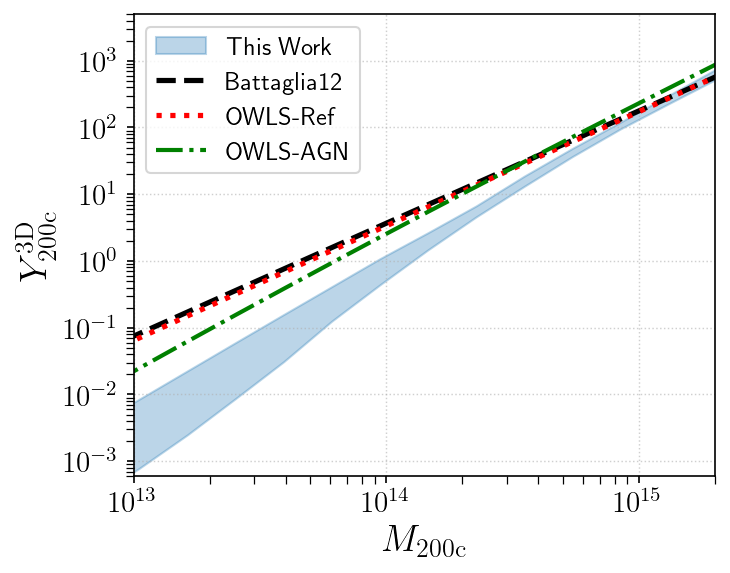

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4), dpi=150)

# Fill region with transparency
plt.fill_between(M_array, Ymin, Ymax, alpha=0.3, color='tab:blue', label='This Work')

# Plot main curve with improved styling
plt.plot(M_array, Y_B12_all, label=r'Battaglia12', lw=2.5, color='black', ls='--')
plt.plot(M_array, Y_owls_all_ref, label=r'OWLS-Ref', lw=2.5, color='red', ls=':')
plt.plot(M_array, Y_owls_all_agn, label=r'OWLS-AGN', lw=2, color='green', ls='-.')

# Log scales for better visualization
plt.xscale('log')
plt.yscale('log')

# Axis labels with LaTeX-style formatting
plt.xlabel(r'$M_{\rm 200c}$', fontsize=18)
plt.ylabel(r'$Y^{\rm 3D}_{\rm 200c}$', fontsize=18)

# Improved axis limits
plt.xlim(1e13, 2e15)
plt.ylim(6e-4, 5e3)

# Improved legend with frame and better positioning
plt.legend(fontsize=12, frameon=True, loc='best')

# Better tick formatting for readability
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tick_params(axis='both', which='minor', labelsize=12, length=4)

# Grid with transparency for better visualization
# plt.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.6)
plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)

# Save figure with high quality
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/'
# plt.savefig(sdir + 'YM.pdf', bbox_inches='tight', dpi=300)

plt.show()



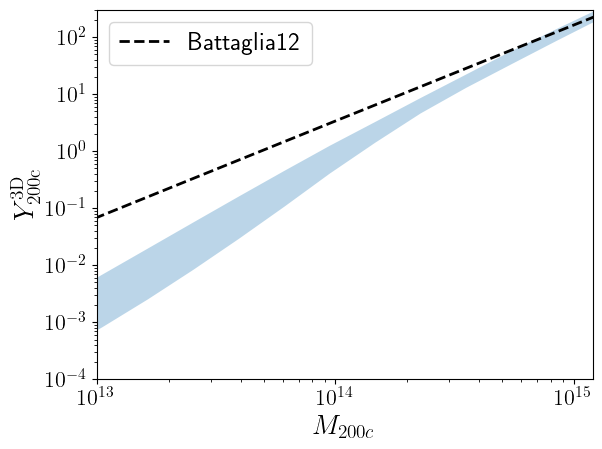

In [35]:
pl.figure()
pl.fill_between(M_array, Ymin, Ymax, alpha=0.3)
pl.plot(M_array, Y_B12_all, label=r'Battaglia12', lw=2.0, color='k', ls='--')
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$M_{200c}$', fontsize=20)
pl.ylabel(r'$Y^{\rm 3D}_{\rm 200c}$', fontsize=20)
pl.xlim(1e13, 1.2e15)
pl.ylim(1e-4, 3e2)
pl.legend(fontsize=18)
pl.tick_params(axis='both', which='major', labelsize=16)
pl.tick_params(axis='both', which='minor', labelsize=16)
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/'
pl.savefig(sdir + 'YM.pdf', bbox_inches='tight', dpi=300)

pl.show()



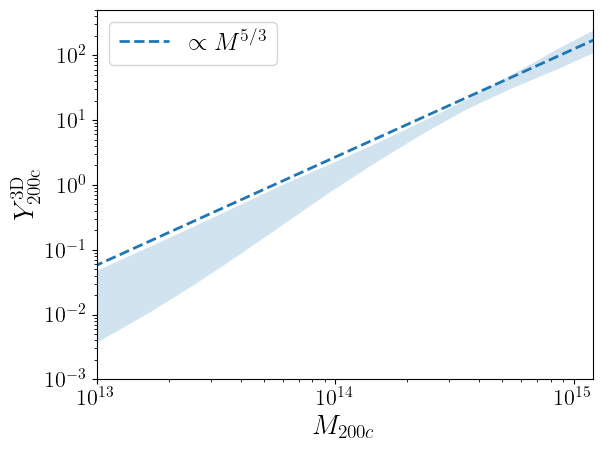

In [26]:
pl.figure()
# for ji in range(len(indsel)):
    # pl.plot(M_array, 1.8*Y_model_all_samp[ji],  lw=2.0)
pl.fill_between(M_array, Ymin, Ymax, alpha=0.2)
# pl.plot(M_array, Y_ss_all, label='SS', lw=2.0)
pl.plot(M_array, 1.25e-23 * (M_array**(5/3.)), label=r'$\propto M^{5/3}$', lw=2.0, ls='--')
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$M_{200c}$', fontsize=20)
pl.ylabel(r'$Y^{\rm 3D}_{\rm 200c}$', fontsize=20)
pl.xlim(1e13, 1.2e15)
pl.ylim(1e-3, 5e2)
pl.legend(fontsize=18)
pl.tick_params(axis='both', which='major', labelsize=16)
pl.tick_params(axis='both', which='minor', labelsize=16)
# pl.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/Y_M_bestfit.png', bbox_inches='tight', dpi=300)
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/'
# pl.savefig(sdir + 'YM.pdf', bbox_inches='tight', dpi=300)

pl.show()



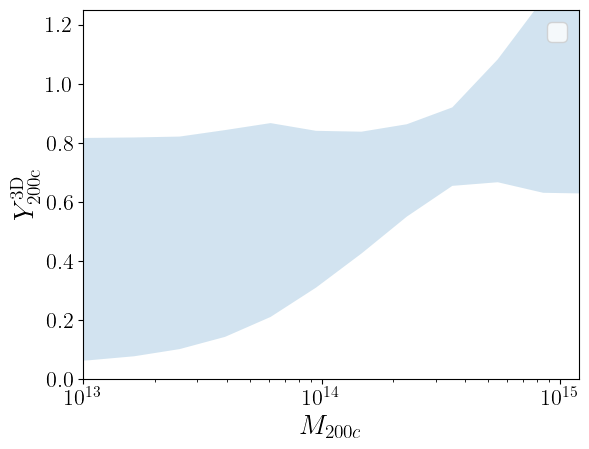

In [28]:
pl.figure()
# for ji in range(len(indsel)):
    # pl.plot(M_array, 1.8*Y_model_all_samp[ji],  lw=2.0)
pl.fill_between(M_array, Ymin/(1.25e-23 * (M_array**(5/3.))), Ymax/(1.25e-23 * (M_array**(5/3.))), alpha=0.2)
# pl.plot(M_array, Y_ss_all, label='SS', lw=2.0)
# pl.plot(M_array, 1.25e-24 * (M_array**(5/3.)), label=r'$\propto M^{5/3}$', lw=2.0, ls='--')
pl.xscale('log')
# pl.yscale('log')
pl.xlabel(r'$M_{200c}$', fontsize=20)
pl.ylabel(r'$Y^{\rm 3D}_{\rm 200c}$', fontsize=20)
pl.xlim(1e13, 1.2e15)
pl.ylim(0,1.25)
pl.legend(fontsize=18)
pl.tick_params(axis='both', which='major', labelsize=16)
pl.tick_params(axis='both', which='minor', labelsize=16)
# pl.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/Y_M_bestfit.png', bbox_inches='tight', dpi=300)
pl.show()



In [25]:
# B12_test.Pe_mat_physical


/tmp/ipykernel_3746232/3534550581.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Y_jM = np.trapz(4 * np.pi * r_array_jM**3 * Pe_jM, np.log(r_array_jM))


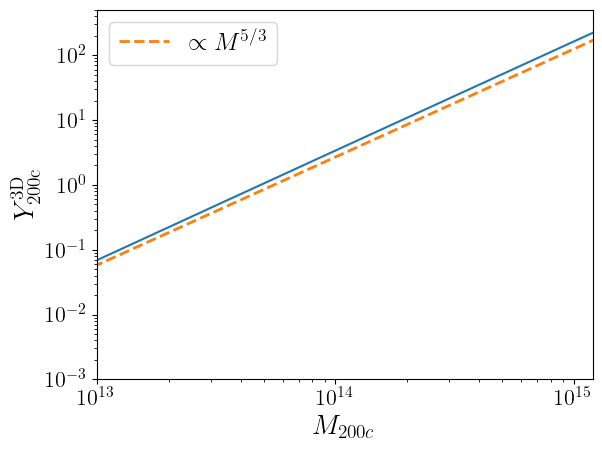

In [11]:
pl.figure()
# for ji in range(len(indsel)):
    # pl.plot(M_array, 1.8*Y_model_all_samp[ji],  lw=2.0)
# pl.fill_between(M_array, Ymin, Ymax, alpha=0.2)
pl.plot(M_array, Y_model_all)
# pl.plot(M_array, Y_ss_all, label='SS', lw=2.0)
pl.plot(M_array, 1.25e-23 * (M_array**(5/3.)), label=r'$\propto M^{5/3}$', lw=2.0, ls='--')
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$M_{200c}$', fontsize=20)
pl.ylabel(r'$Y^{\rm 3D}_{\rm 200c}$', fontsize=20)
pl.xlim(1e13, 1.2e15)
pl.ylim(1e-3, 5e2)
pl.legend(fontsize=18)
pl.tick_params(axis='both', which='major', labelsize=16)
pl.tick_params(axis='both', which='minor', labelsize=16)
# pl.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/Y_M_bestfit.png', bbox_inches='tight', dpi=300)
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/'
# pl.savefig(sdir + 'YM.pdf', bbox_inches='tight', dpi=300)

pl.show()

